In [9]:
import os
import sys
import shutil
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt

from IPython.display    import display, HTML
from datetime           import date
from sklearn.model_selection    import train_test_split
from methods.Modeling   import Catboost_classificator
from methods.Estimators import (
                                    matrix, 
                                    get_metrics, 
                                    clear_only_files,
                                    BinaryClassificationEvaluator, 
                                    find_best_threshold,
                                    sampling_test,
                                    perform_rfecv,
                                    intervals,
                                    find_feature_importance_catboost,
                                    error_matrix,
                                    total_stata,
                                    mean_absolute_percentage_error,
                                    calculate_columnwise_mape,
                                    save_importances,
                                    plot_roc_lift,
                                    plot_tpr_tnr_intersection,
                                    find_best_threshold_prev,
                                    plot_optimal_proba
                                )

from sklearn.metrics   import (
                                precision_recall_curve,
                                accuracy_score,
                                recall_score,
                                precision_score,
                                roc_auc_score,
                                f1_score
                                
                            )


In [10]:
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(HTML("<style>.container { width:99% !important; }</style>"))
pd.options.display.float_format = '{:,.3f}'.format
pd.set_option('display.max_columns', None)
# ширина каждого столбца (в символах)
pd.set_option('display.max_colwidth', None)

# Фиксируем ВСЕ случайные seed
np.random.seed(0)
import random
random.seed(0)

In [11]:
path = f'prepared_data/data_for_modeling.pickle'
# загрузка данных
with open(path, 'rb') as f:
    samples = pickle.load(f)

# проверим, какие ключи есть в загруженном словаре
print("Ключи в samples:", samples.keys())

Ключи в samples: dict_keys(['train', 'valid', 'test', 'target', 'reasons_df', 'info_fields', 'features', 'cat_features', 'features_intervals'])


In [12]:
train        = samples['train']
valid        = samples['valid']
test         = samples['test']
info         = samples['info_fields']
features     = sorted(samples['features'])
cat_features = samples['cat_features']
target       = samples['target']
reasons_df   = samples['reasons_df']
features_intervals = samples['features_intervals']
build = pd.concat([train, valid])

# Разбиваем на подвыборки

In [13]:
print('======= Распределение таргетов: =======')

print('train:')
print(train[target].value_counts(normalize=True))
print('valid:')
print(valid[target].value_counts(normalize=True))
print('test:')
print(test[target].value_counts(normalize=True))
print('build:')
print(build[target].value_counts(normalize=True))

======= Распределение таргетов: =======
train:
target
0   0.514
1   0.486
Name: proportion, dtype: float64
valid:
target
0   0.514
1   0.486
Name: proportion, dtype: float64
test:
target
0   0.514
1   0.486
Name: proportion, dtype: float64
build:
target
0   0.514
1   0.486
Name: proportion, dtype: float64


In [14]:
print('======= Размер выборок: =======')

print('train:')
print(train.shape)
print('valid:')
print(valid.shape)
print('test:')
print(test.shape)
print('build:')
print(build.shape)

======= Размер выборок: =======
train:
(88772, 26)
valid:
(22194, 26)
test:
(27742, 26)
build:
(110966, 26)


In [15]:
X_train, y_train = train[features], train[target]
X_valid, y_valid = valid[features], valid[target]
X_test, y_test   = test[features], test[target]

# Моделирование

In [34]:
# params = {
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     'learning_rate': 0.01,
#     'depth': 7,
#     'l2_leaf_reg': 2,
#     'od_type': 'Iter',
#     'od_wait': 200,
#     'iterations': 2000,  # Больше итераций
#     'auto_class_weights': 'Balanced',
#     'bootstrap_type': 'Bernoulli',
#     'subsample': 0.9,
#     'border_count': 128,  # Увеличиваем количество биннинга
#     'grow_policy': 'SymmetricTree',  # Для более стабильных вероятностей
#     'score_function': 'L2',  # Для лучшей калибровки
#     'min_data_in_leaf': 50,  # Минимум данных в листе
# #     'posterior_sampling': True,  # Включает байесовскую калибровку
# }
params = {
    'auto_class_weights': 'Balanced',
    'loss_function': 'Logloss',
    'early_stopping_rounds': 100,
    'eval_metric': 'AUC',
    'learning_rate':0.05,
    
} 

In [35]:
# объект класса Катбуст
clf_object = Catboost_classificator()
model = clf_object.catboost_base_model_func(X_train[features], y_train, 
                                            X_valid[features], y_valid, 
                                            cat_features , 
                                            params)

0:	test: 0.5266653	best: 0.5266653 (0)	total: 16.9ms	remaining: 16.9s
50:	test: 0.5504773	best: 0.5520443 (38)	total: 711ms	remaining: 13.2s
100:	test: 0.5550964	best: 0.5551158 (90)	total: 1.36s	remaining: 12.1s
150:	test: 0.5580038	best: 0.5580038 (150)	total: 2.03s	remaining: 11.4s
200:	test: 0.5586578	best: 0.5590632 (178)	total: 2.68s	remaining: 10.6s
250:	test: 0.5619106	best: 0.5619337 (244)	total: 3.36s	remaining: 10s
300:	test: 0.5648224	best: 0.5649011 (298)	total: 3.97s	remaining: 9.21s
350:	test: 0.5663677	best: 0.5664552 (346)	total: 4.58s	remaining: 8.48s
400:	test: 0.5687275	best: 0.5687842 (399)	total: 5.2s	remaining: 7.77s
450:	test: 0.5705404	best: 0.5705404 (450)	total: 5.82s	remaining: 7.08s
500:	test: 0.5711977	best: 0.5714023 (470)	total: 6.43s	remaining: 6.41s
550:	test: 0.5718213	best: 0.5721729 (545)	total: 7.05s	remaining: 5.75s
600:	test: 0.5736913	best: 0.5737154 (599)	total: 7.68s	remaining: 5.1s
650:	test: 0.5742259	best: 0.5743058 (644)	total: 8.3s	remain

## importances

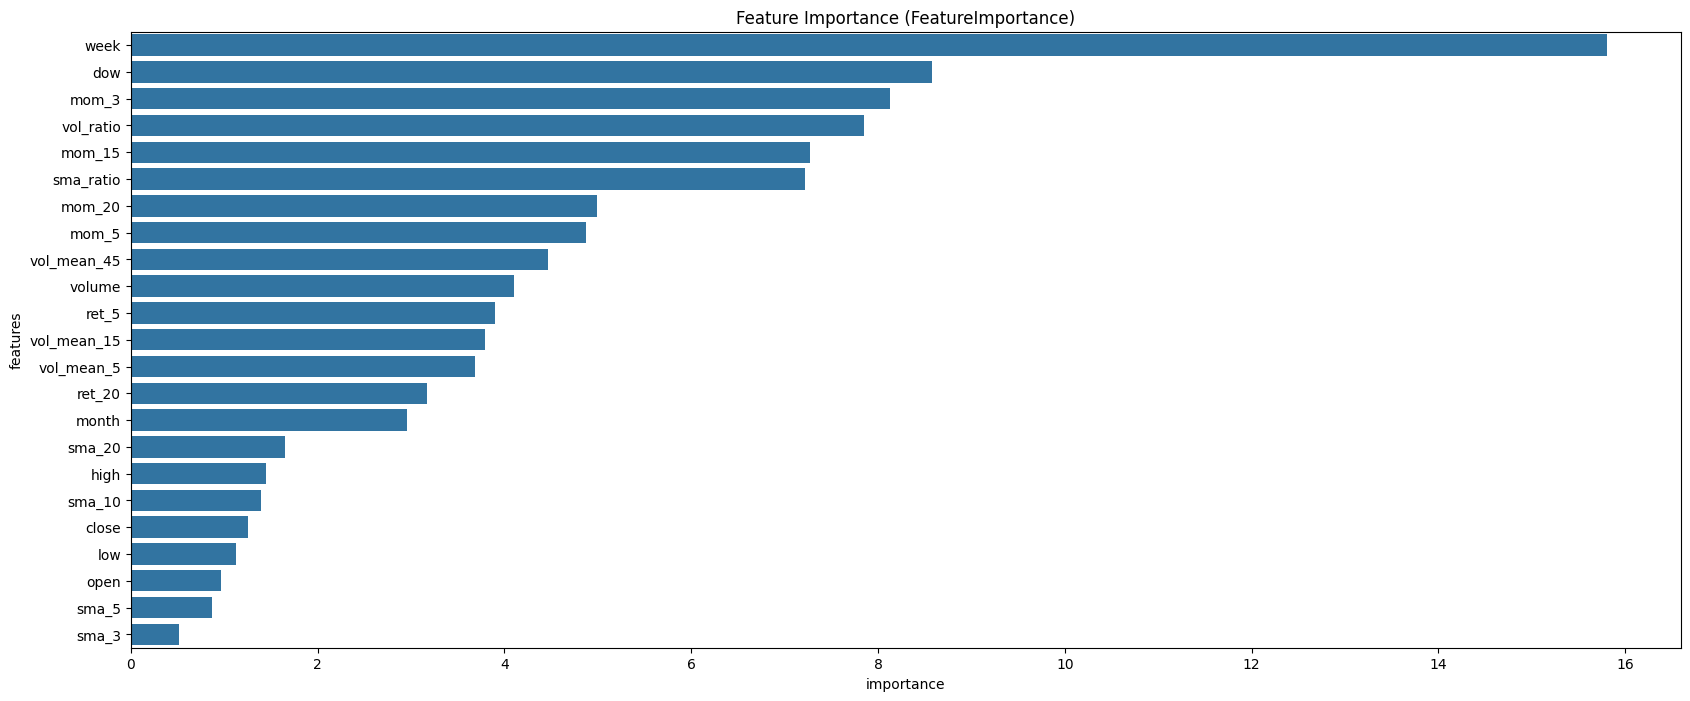

In [18]:
features_importances  = find_feature_importance_catboost(X_train[features], y_train, cat_features, model, 'FeatureImportance', '', False)

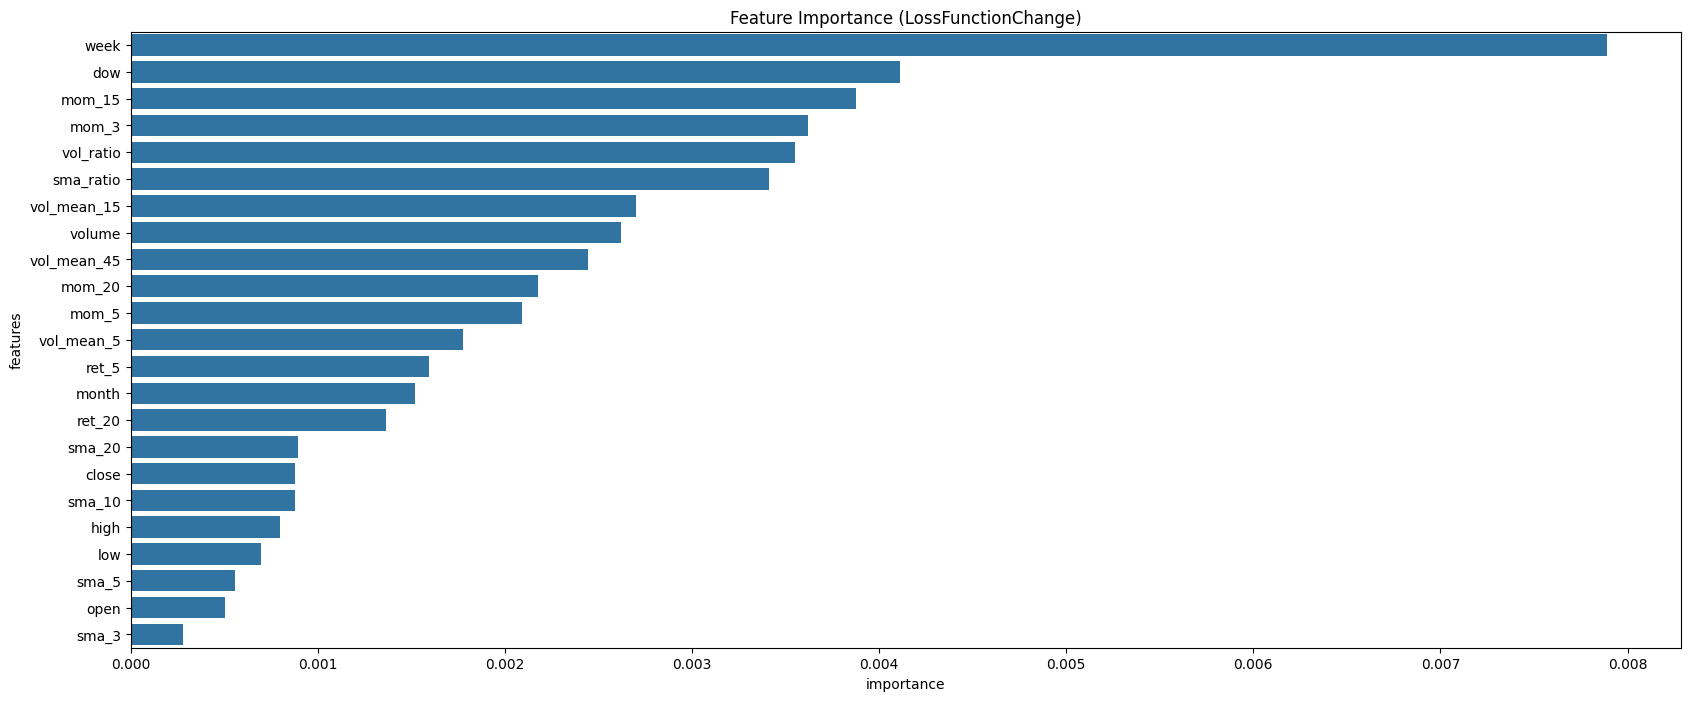

In [19]:
loss_importances      = find_feature_importance_catboost(X_train[features], y_train, cat_features, model, 'LossFunctionChange', '', False)

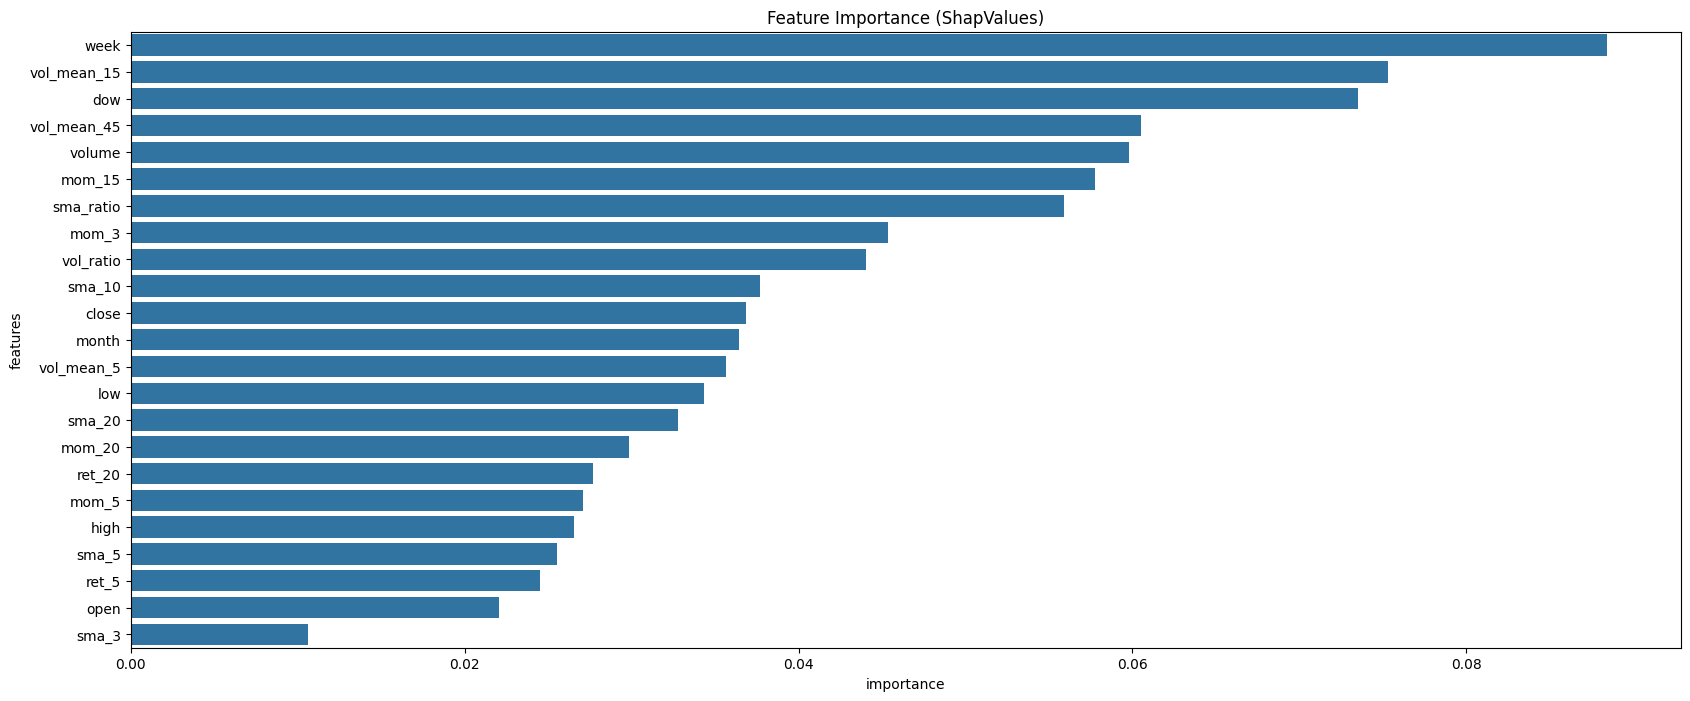

In [20]:
sharp_importances     = find_feature_importance_catboost(X_train[features], y_train, cat_features, model, 'ShapValues', '', False)

# Оптимальный трешхолд по F1

--------Оптимальный трешхолд по F1 -------


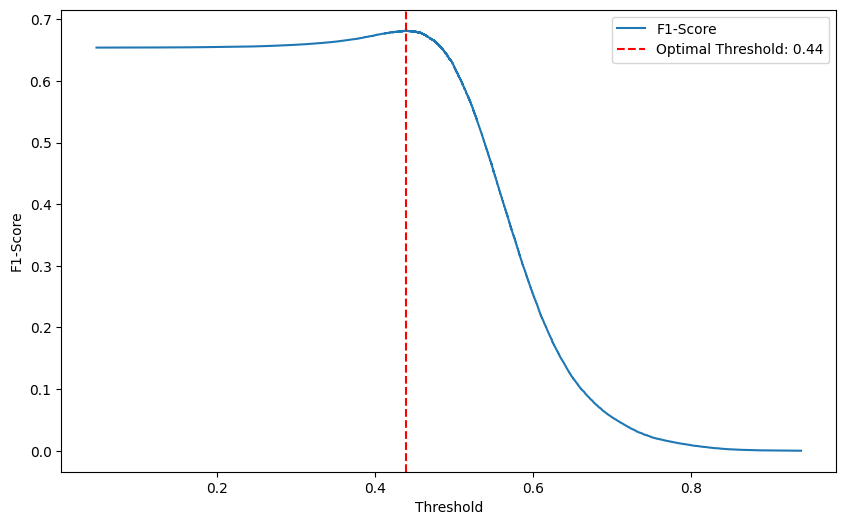

f1_threshold - 0.44, на модели catboost_build_model


In [21]:
print('--------Оптимальный трешхолд по F1 -------')
build_pred_proba = model.predict_proba(build[model.feature_names_])[:, 1]
f1_threshold = plot_optimal_proba(y_true = build[target], y_pred_prob = build_pred_proba, path = '', verbose = False)

f1_threshold = round(f1_threshold, 2)

print(f'f1_threshold - {f1_threshold}, на модели catboost_build_model')

In [22]:
print('------------- Метрики ------------- ')
y_pred_prob = model.predict_proba(X_test[features])[:, 1]  # Predict probabilities for the positive class
y_pred = (y_pred_prob >= f1_threshold).astype(int) #

methods_dict = {
    'binary': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод', 
    'micro': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.', 
    'macro': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)', 
    'weighted': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'
}

metrics_dict = {
    'Accuracy': round(accuracy_score(y_test, y_pred), 3),
    'ROC-AUC': round(roc_auc_score(y_test, y_pred_prob), 3), 
}

for metric_methods, desription in methods_dict.items():
    metrics_dict[metric_methods] = {
        'Метрики': {
            'Precision': round(precision_score(y_test, y_pred, average = metric_methods), 3),
            "Recall"   : round(recall_score(y_test, y_pred, average = metric_methods), 3),
            "F1"       : round(f1_score(y_test, y_pred, average = metric_methods), 3)
        },
        'Описание': desription
}

display(metrics_dict)


------------- Метрики ------------- 


{'Accuracy': 0.524,
 'ROC-AUC': 0.578,
 'binary': {'Метрики': {'Precision': 0.506, 'Recall': 0.851, 'F1': 0.635},
  'Описание': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод'},
 'micro': {'Метрики': {'Precision': 0.524, 'Recall': 0.524, 'F1': 0.524},
  'Описание': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.'},
 'macro': {'Метрики': {'Precision': 0.555, 'Recall': 0.533, 'F1': 0.476},
  'Описание': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)'},
 'weighted': {'Метрики': {'Precision': 0.556, 'Recall': 0.524, 'F1': 0.471},
  'Описание': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'}}

МАТРИЦА ОШИБОК
ROC-AUC: 0.57752569360286


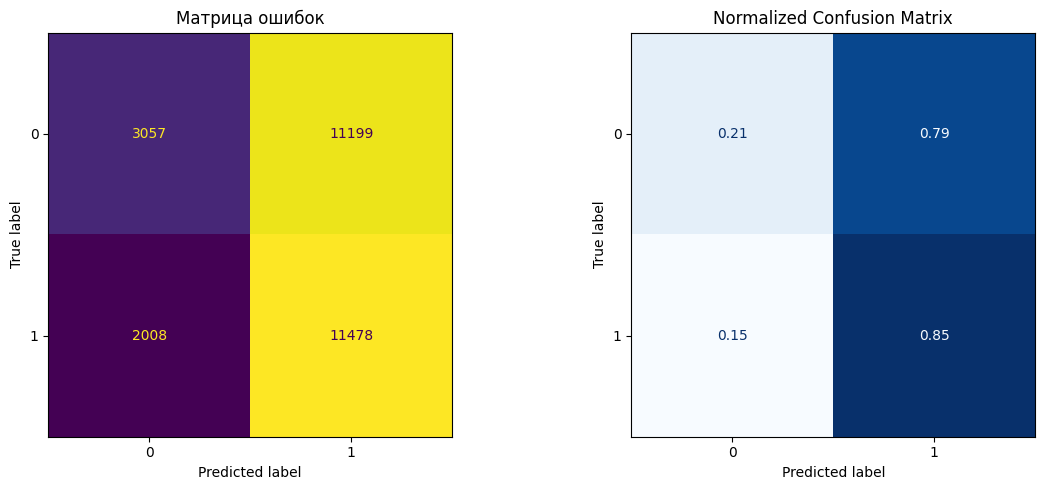

In [23]:
print('МАТРИЦА ОШИБОК')

error_matrix(X_test, y_test, model,f1_threshold)

------------- Графики ------------- 


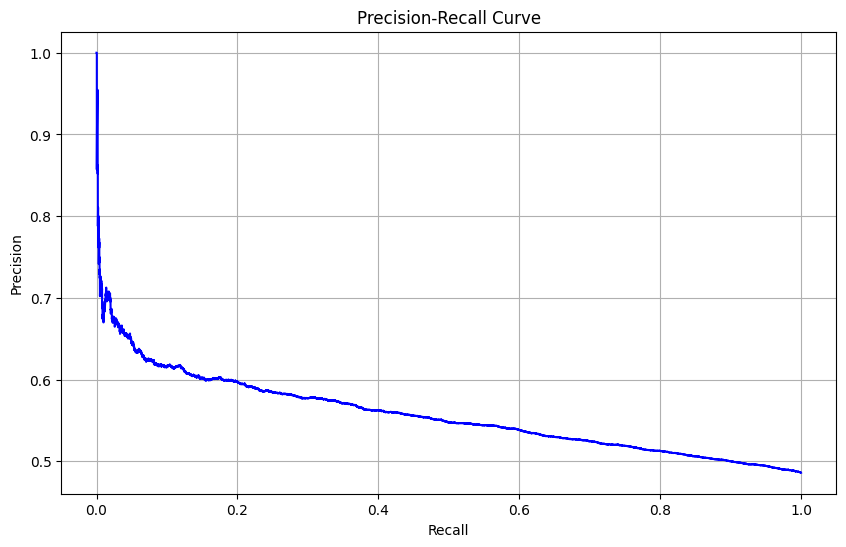

None

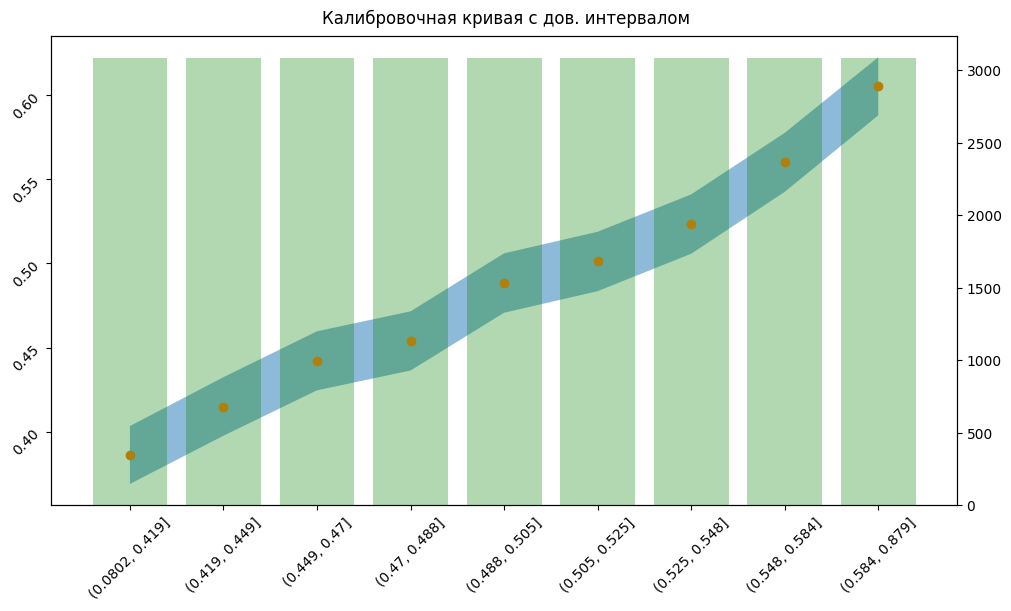

None

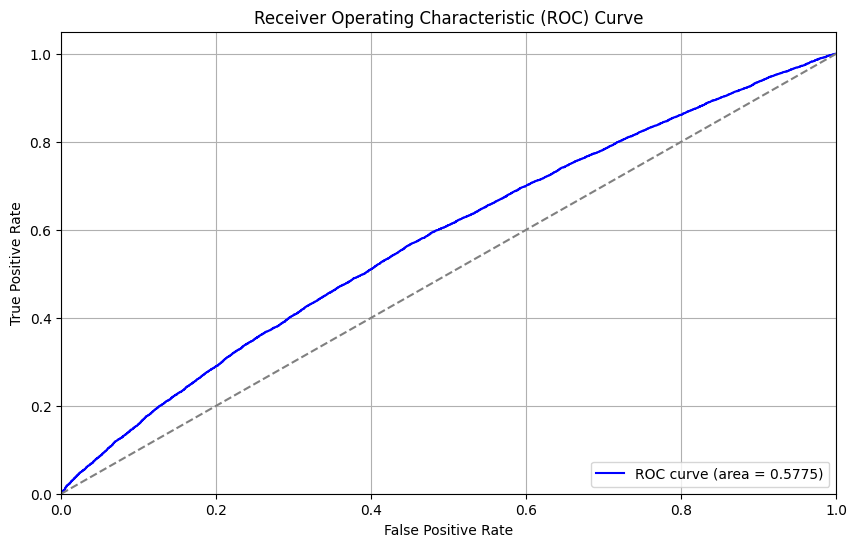

None

In [24]:
print('------------- Графики ------------- ')
metrics_graphs = BinaryClassificationEvaluator(y_test, y_pred, y_pred_prob)
display(metrics_graphs.plot_precision_recall_curve(path = '', verbose =False))
display(metrics_graphs.plot_calibration(path = '', verbose =False))
display(metrics_graphs.plot_roc_curve(path = '', verbose =False))

# Оптимальный трешхолд по FPR/TPR

--------Оптимальный трешхолд по FPR/TPR--------
threshold - 0.5, на модели model


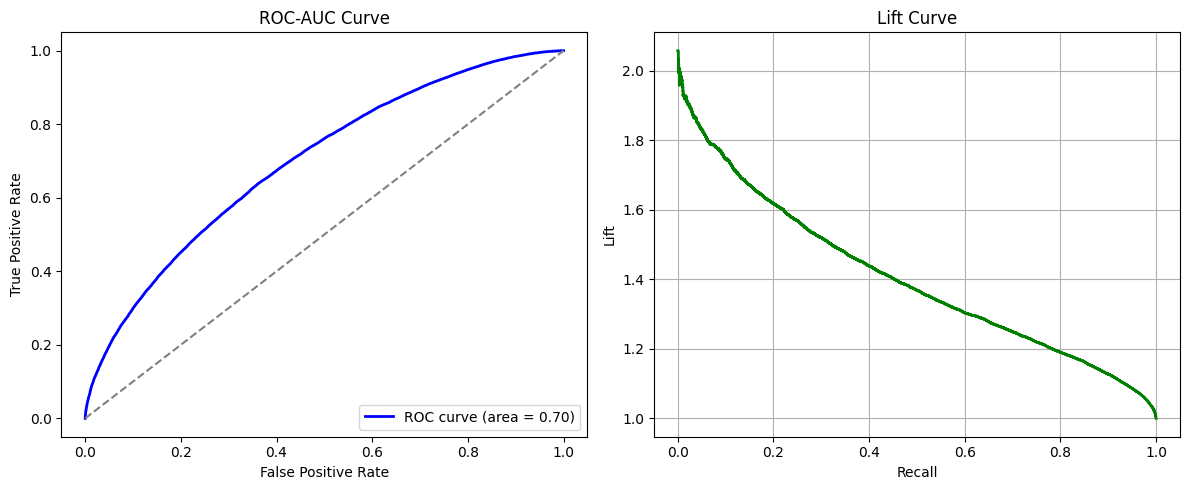

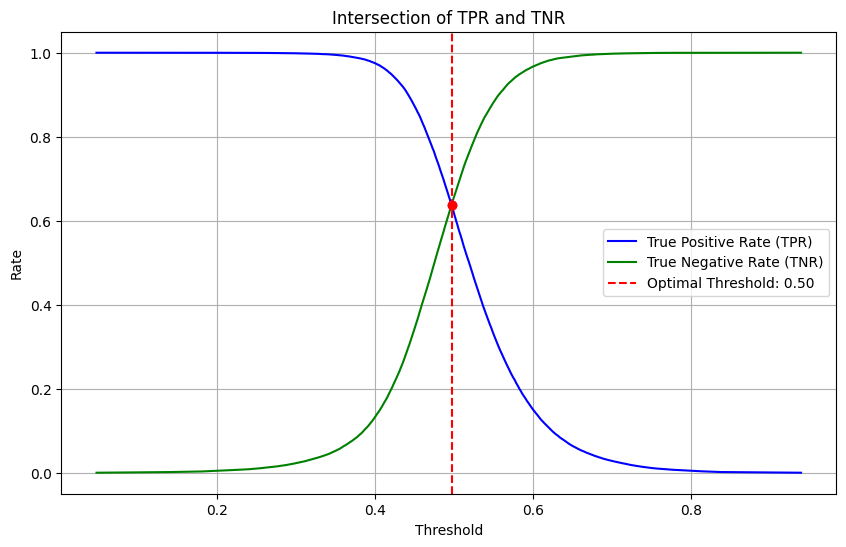

Optimal Threshold: 0.50
TPR at Optimal Threshold: 0.64
TNR at Optimal Threshold: 0.64


In [25]:
print('--------Оптимальный трешхолд по FPR/TPR--------')

build_pred_proba = model.predict_proba(build[model.feature_names_])[:, 1]
threshold, optimal_tpr, optimal_tnr, thresholds, fpr, tpr, tnr = find_best_threshold(y_true = build[target], y_pred_proba = build_pred_proba)
threshold  = round(threshold, 2)
build_pred = (build_pred_proba >= threshold).astype(int)
print(f'threshold - {threshold}, на модели model')

# графики с трешхолдами / verbose = FALSE - чтобы графики не сохранялись, просто посмотреть на них
plot_roc_lift(y_true = build[target], y_pred_proba = build_pred_proba, path = '', verbose= False)
plot_tpr_tnr_intersection(y_true = build[target], y_pred_proba = build_pred_proba, path = '', verbose= False)

------------- Графики ------------- 


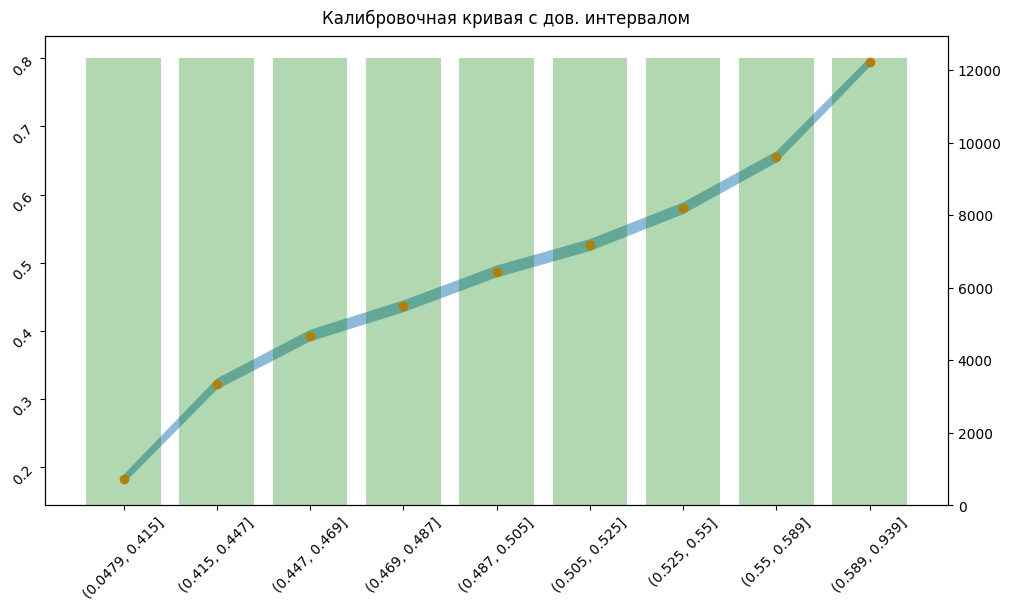

None

In [26]:
print('------------- Графики ------------- ')
metrics_graphs = BinaryClassificationEvaluator(build[target], build_pred, build_pred_proba)
display(metrics_graphs.plot_calibration(path = '', verbose =False))

In [27]:
print('------------- Метрики ------------- ')
y_pred_prob = model.predict_proba(X_test[features])[:, 1]  # Predict probabilities for the positive class
y_pred = (y_pred_prob >= threshold).astype(int) #

methods_dict = {
    'binary': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод', 
    'micro': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.', 
    'macro': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)', 
    'weighted': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'
}

metrics_dict = {
    'Accuracy': round(accuracy_score(y_test, y_pred), 3),
    'ROC-AUC': round(roc_auc_score(y_test, y_pred_prob), 3), 
}

for metric_methods, desription in methods_dict.items():
    metrics_dict[metric_methods] = {
        'Метрики': {
            'Precision': round(precision_score(y_test, y_pred, average = metric_methods), 3),
            "Recall"   : round(recall_score(y_test, y_pred, average = metric_methods), 3),
            "F1"       : round(f1_score(y_test, y_pred, average = metric_methods), 3)
        },
        'Описание': desription
}

display(metrics_dict)


------------- Метрики ------------- 


{'Accuracy': 0.557,
 'ROC-AUC': 0.578,
 'binary': {'Метрики': {'Precision': 0.545, 'Recall': 0.538, 'F1': 0.542},
  'Описание': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод'},
 'micro': {'Метрики': {'Precision': 0.557, 'Recall': 0.557, 'F1': 0.557},
  'Описание': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.'},
 'macro': {'Метрики': {'Precision': 0.557, 'Recall': 0.557, 'F1': 0.557},
  'Описание': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)'},
 'weighted': {'Метрики': {'Precision': 0.557, 'Recall': 0.557, 'F1': 0.557},
  'Описание': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'}}

МАТРИЦА ОШИБОК
ROC-AUC: 0.57752569360286


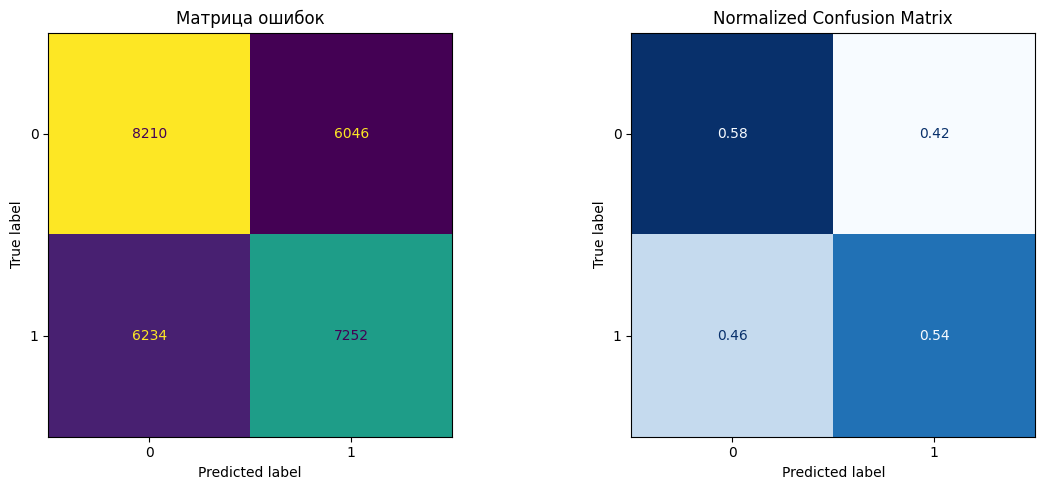

In [28]:
print('МАТРИЦА ОШИБОК')

error_matrix(X_test[features], y_test, model,threshold)

------------- Графики ------------- 


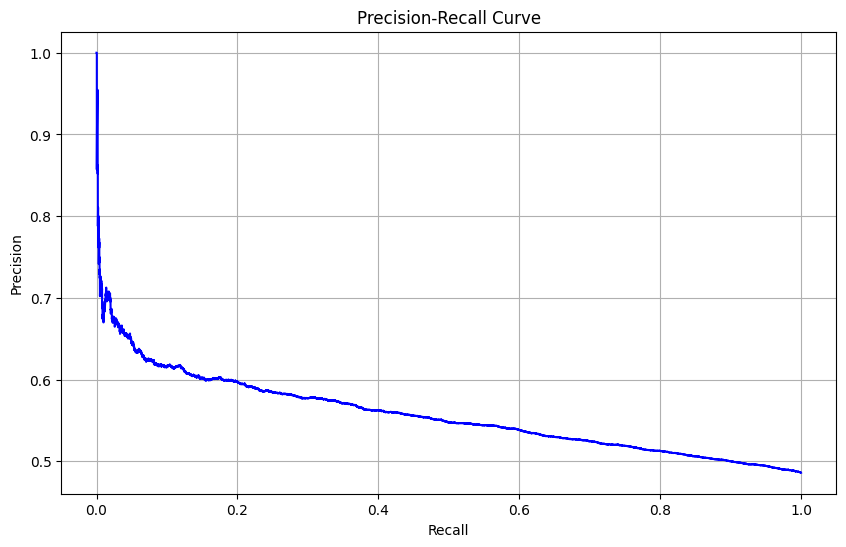

None

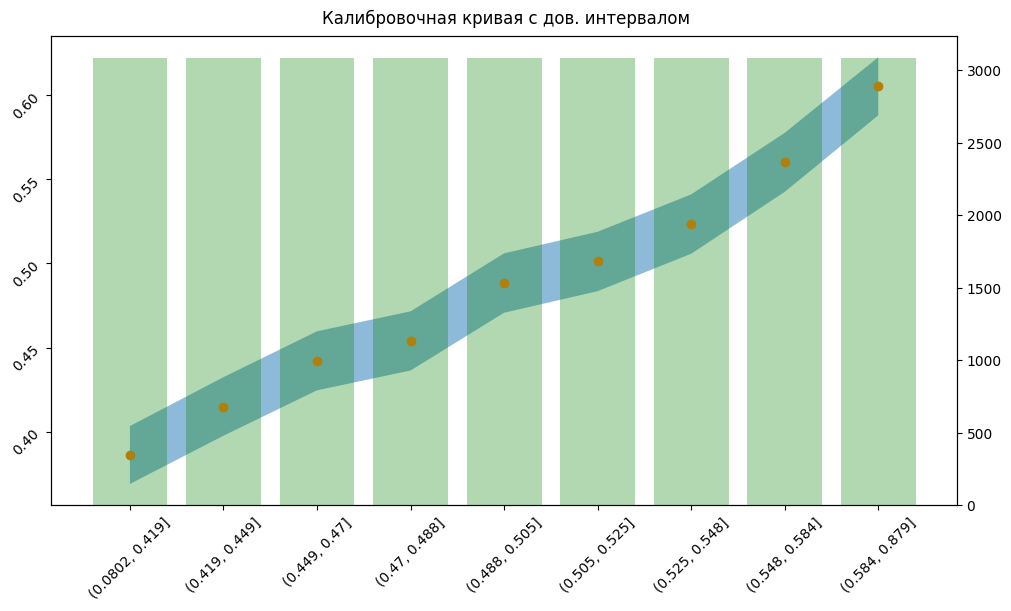

None

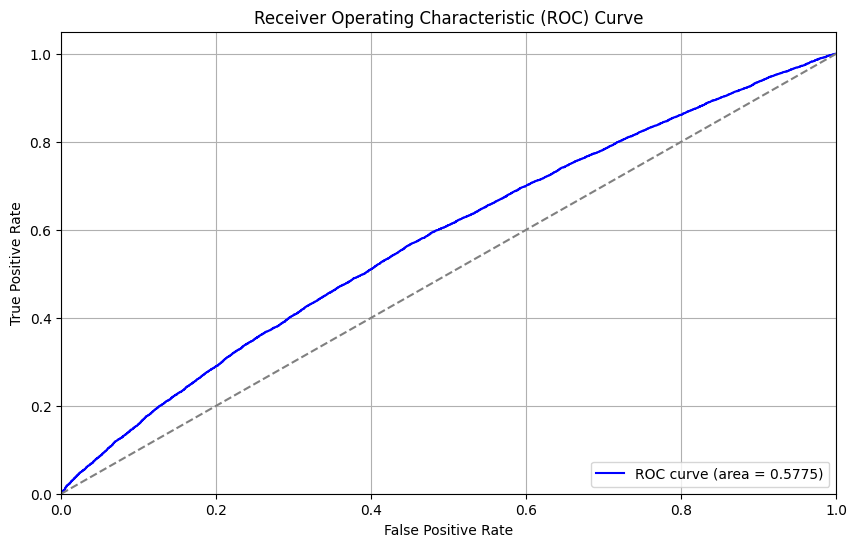

None

In [29]:
print('------------- Графики ------------- ')
metrics_graphs = BinaryClassificationEvaluator(y_test, y_pred, y_pred_prob)
display(metrics_graphs.plot_precision_recall_curve(path = '', verbose =False))
display(metrics_graphs.plot_calibration(path = '', verbose =False))
display(metrics_graphs.plot_roc_curve(path = '', verbose =False))

# Анализ по decile

In [30]:
y_pred_prob_build = model.predict_proba(build[features])[:,1]
# 1. Собираем DataFrame
df_lift = pd.DataFrame({
    'y_true': build[target].values,
    'y_score': y_pred_prob_build
})

# 2. Сортируем по скору (по убыванию)
df_lift = df_lift.sort_values('y_score', ascending=False).reset_index(drop=True)

# 3. Добавляем номер дециля (1 = top 10%)
df_lift['decile'] = pd.qcut(
    df_lift.index,
    q=20,
    labels=False
) + 1

# 4. Базовый CTR по всему тесту
base_ctr = df_lift['y_true'].mean()

# 5. Агрегация по децилям
decile_stats = (
    df_lift
    .groupby('decile')
    .agg(
        mean_score  = ('y_score', 'mean'),
        min_score   = ('y_score', 'min'),
        max_score   = ('y_score', 'max'),
        bids = ('y_true', 'count'),
        clicks      = ('y_true', 'sum'),     
    )
    .reset_index()
    .sort_values('decile')
)

# 6. CTR и Lift
decile_stats['ctr'] = decile_stats['clicks'] / decile_stats['bids']
decile_stats['lift'] = decile_stats['ctr'] / base_ctr

# 7. Cumulative Gain
total_clicks = decile_stats['clicks'].sum()
decile_stats['cum_clicks'] = decile_stats['clicks'].cumsum()
decile_stats['gain'] = decile_stats['cum_clicks'] / total_clicks

# 8. Красивое форматирование
decile_stats['ctr'] = decile_stats['ctr'].round(4)
decile_stats['lift'] = decile_stats['lift'].round(3)
decile_stats['gain'] = decile_stats['gain'].round(3)
decile_stats['mean_score'] = decile_stats['mean_score'].round(2)
decile_stats['min_score'] = decile_stats['min_score'].round(2)
decile_stats['max_score'] = decile_stats['max_score'].round(2)
decile_stats_build = decile_stats.copy()
decile_stats_build

,decile,mean_score,min_score,max_score,bids,clicks,ctr,lift,cum_clicks,gain
0,1,0.690,0.630,0.940,5549,4776,0.861,1.771,4776,0.089
1,2,0.610,0.590,0.630,5548,4135,0.745,1.533,8911,0.165
2,3,0.580,0.570,0.590,5548,3863,0.696,1.432,12774,0.237
3,4,0.560,0.560,0.570,5549,3588,0.647,1.330,16362,0.303
4,5,0.550,0.540,0.560,5548,3365,0.607,1.248,19727,0.366
5,6,0.540,0.530,0.540,5548,3231,0.582,1.198,22958,0.426
6,7,0.530,0.520,0.530,5548,3106,0.560,1.152,26064,0.483
7,8,0.520,0.510,0.520,5549,2916,0.525,1.081,28980,0.537
8,9,0.510,0.500,0.510,5548,2842,0.512,1.054,31822,0.590
9,10,0.500,0.500,0.500,5548,2813,0.507,1.043,34635,0.642


In [31]:
bins = (
    decile_stats_build
    .sort_values('decile')
    [['decile', 'min_score', 'max_score', 'ctr', 'lift']]
    .reset_index(drop=True)
)

bins.loc[bins['max_score'].idxmax(), 'max_score'] = 1
bins.loc[bins['min_score'].idxmin(), 'min_score'] = 0
intervals = pd.IntervalIndex.from_arrays(
    bins['min_score'],
    bins['max_score'],
    closed='left'
)
intervals[:10]

IntervalIndex([ [0.63, 1.0), [0.59, 0.63), [0.57, 0.59), [0.56, 0.57),
               [0.54, 0.56), [0.53, 0.54), [0.52, 0.53), [0.51, 0.52),
                [0.5, 0.51),   [0.5, 0.5)],
              dtype='interval[float64, left]')

In [32]:
scoring_lift = bins[['min_score', 'max_score', 'lift']]

In [33]:
y_pred_prob_test = model.predict_proba(test[features])[:, 1]

df_test = pd.DataFrame({
    'y_true': test[target].values,
    'y_score': y_pred_prob_test
})

df_test['decile'] = pd.cut(
    df_test['y_score'],
    bins=intervals
)

# вместо интервалов подставляем номер дециля
df_test['decile'] = df_test['decile'].map(dict(zip(intervals, bins['decile'])))

# 5. Агрегация по децилям
decile_stats = (
    df_test
    .groupby(['decile'])
    .agg(

        min_score   = ('y_score', 'min'),
        max_score   = ('y_score', 'max'),
        mean_score  = ('y_score', 'mean'),
        bids = ('y_true', 'count'),
        clicks = ('y_true', 'sum'), 
        
    )
    .reset_index()
    .sort_values('decile')
)
decile_stats      = decile_stats_build[['decile', 'lift']].merge(decile_stats)
decile_stats.columns = ['decile', 'lift',  'min_score', 'max_score', 'mean_score', 'bids', 'clicks']
# 6. CTR и Lift
decile_stats['ctr_test'] = decile_stats['clicks'] / decile_stats['bids']
decile_stats['lift_test'] = decile_stats['ctr_test'] / base_ctr

# 7. Cumulative Gain
total_clicks = decile_stats['clicks'].sum()
decile_stats['cum_clicks'] = decile_stats['clicks'].cumsum()
decile_stats['gain'] = decile_stats['cum_clicks'] / total_clicks

# 8. Красивое форматирование
decile_stats['ctr_test'] = decile_stats['ctr_test'].round(4)
decile_stats['lift_test'] = decile_stats['lift_test'].round(3)
decile_stats['gain'] = decile_stats['gain'].round(3)
decile_stats['mean_score'] = decile_stats['mean_score'].round(2)
decile_stats['min_score'] = decile_stats['min_score'].round(2)
decile_stats['max_score'] = decile_stats['max_score'].round(2)
decile_stats_test = decile_stats.copy()
decile_stats_test

,decile,lift,min_score,max_score,mean_score,bids,clicks,ctr_test,lift_test,cum_clicks,gain
0,1,1.771,0.630,0.880,0.680,1221,773,0.633,1.302,773,0.057
1,2,1.533,0.590,0.630,0.610,1481,884,0.597,1.228,1657,0.123
2,3,1.432,0.570,0.590,0.580,1414,810,0.573,1.178,2467,0.183
3,4,1.330,0.560,0.570,0.560,827,456,0.551,1.134,2923,0.217
4,5,1.248,0.540,0.560,0.550,2170,1188,0.547,1.126,4111,0.305
5,6,1.198,0.530,0.540,0.530,1347,714,0.530,1.090,4825,0.358
6,7,1.152,0.520,0.530,0.530,1517,765,0.504,1.037,5590,0.415
7,8,1.081,0.510,0.520,0.510,1608,813,0.506,1.040,6403,0.475
8,9,1.054,0.500,0.510,0.500,1713,849,0.496,1.020,7252,0.538
9,10,1.043,NaN,NaN,NaN,0,0,NaN,NaN,7252,0.538
